Assignment 4

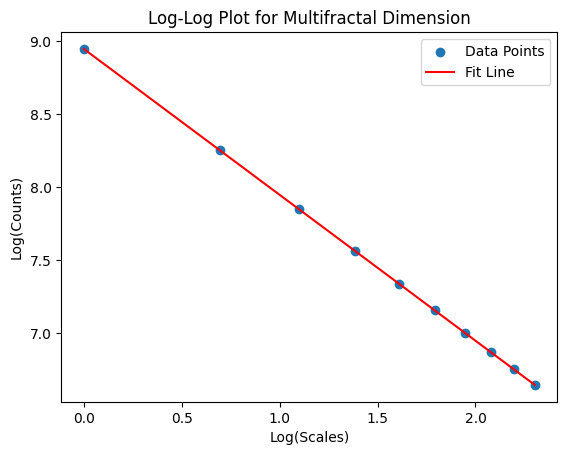

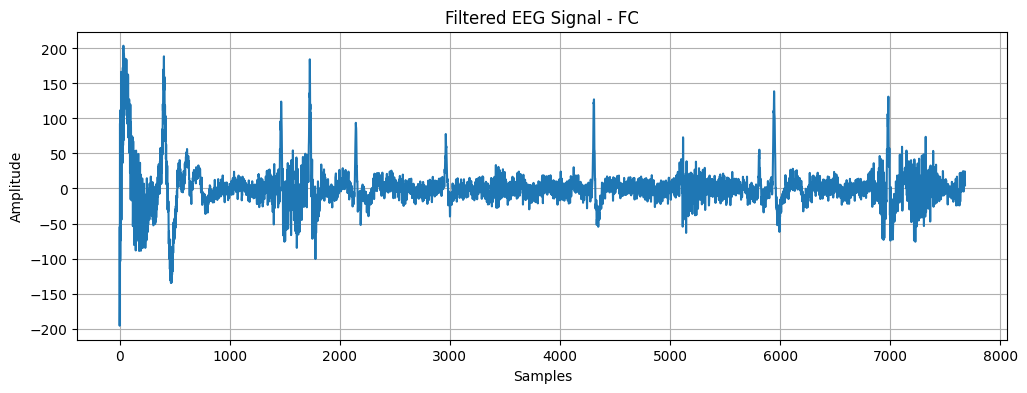

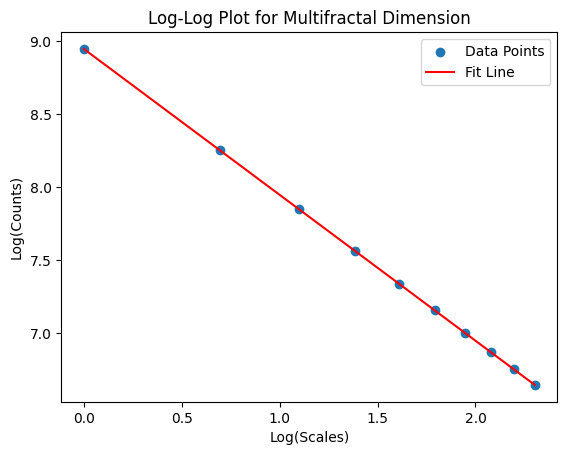

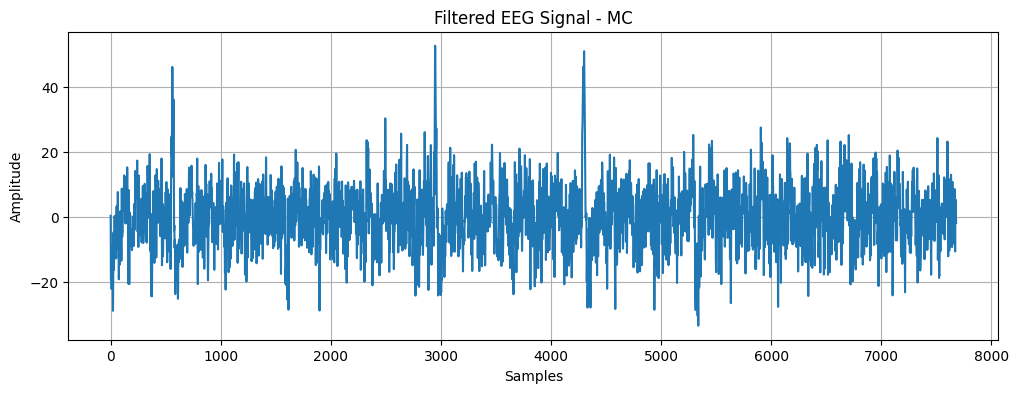

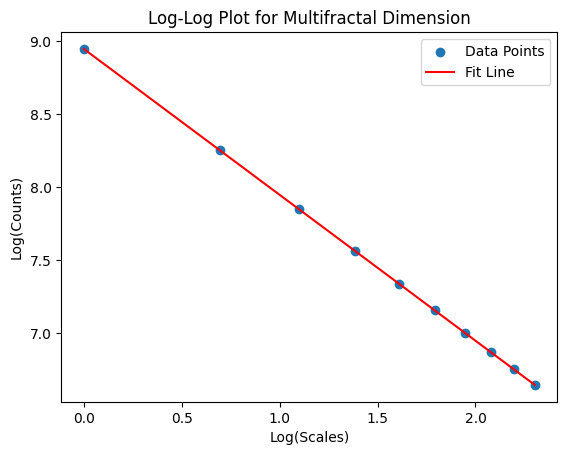

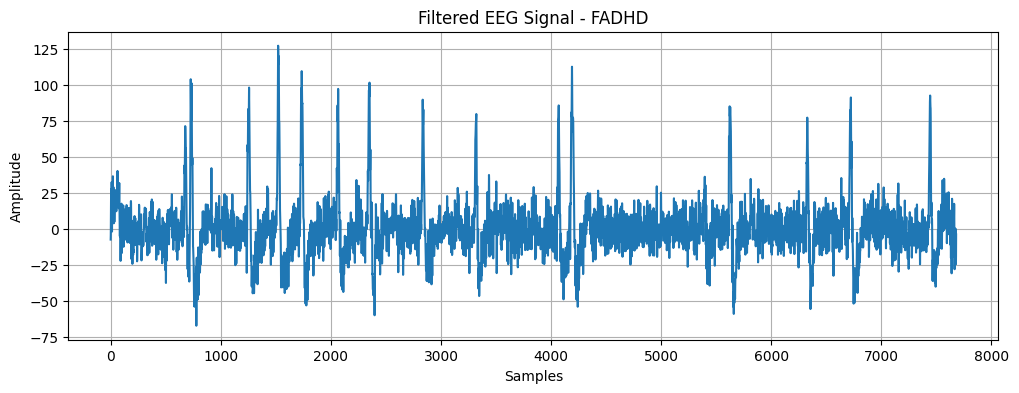

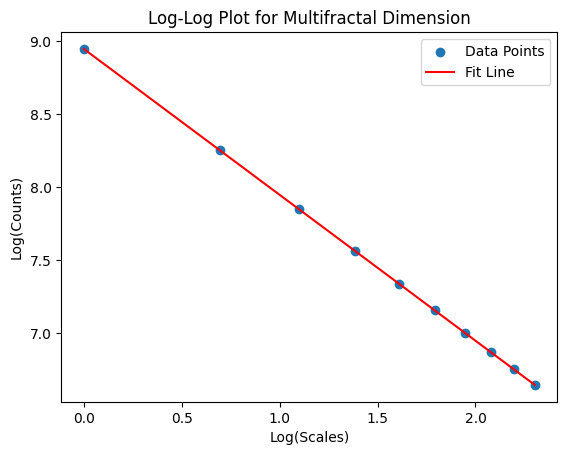

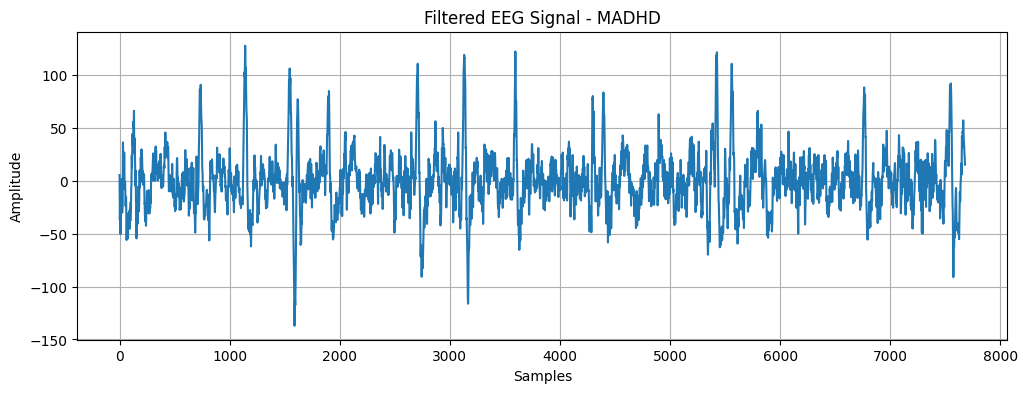


FC Results:
Box-Counting Dimension: 0.9998187691319341
Higuchi Fractal Dimension: 0.7924449326589341
DFA Exponent: 0.4130972747606005
Multifractal Dimension: 0.9998187691319341

MC Results:
Box-Counting Dimension: 0.9998187691319341
Higuchi Fractal Dimension: 0.605530851938614
DFA Exponent: 0.8336805198376348
Multifractal Dimension: 0.9998187691319341

FADHD Results:
Box-Counting Dimension: 0.9998187691319341
Higuchi Fractal Dimension: 0.6812226493293945
DFA Exponent: 0.6433324219847907
Multifractal Dimension: 0.9998187691319341

MADHD Results:
Box-Counting Dimension: 0.9998187691319341
Higuchi Fractal Dimension: 0.4392367200419385
DFA Exponent: 0.8410522298396816
Multifractal Dimension: 0.9998187691319341


In [6]:
import scipy.io as sc
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend

# Loading EEG data from .mat files
FC_data = sc.loadmat(r'/content/FC.mat')
MC_data = sc.loadmat(r'/content/MC.mat')
FADHD_data = sc.loadmat(r'/content/FADHD.mat')
MADHD_data = sc.loadmat(r'/content/MADHD.mat')

# Extracting relevant task data
task_1_data = FC_data['FC'][0][0]
task_2_data = MC_data['MC'][0][0]
task_3_data = FADHD_data['FADHD'][0][0]
task_4_data = MADHD_data['MADHD'][0][0]

# Bandpass filter parameters
lowcut = 0.5  # Lower cutoff frequency
highcut = 50  # Upper cutoff frequency
fs = 256      # Sampling frequency

def butter_bandpass(lowcut, highcut, fs, order=4):
    """Design a Butterworth bandpass filter."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Apply the bandpass filter to the data."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

def box_counting_dimension(x, k_max):
    """Calculate the box-counting dimension of the signal."""
    scales = np.arange(1, k_max + 1)
    counts = []

    for scale in scales:
        count = sum(1 for i in range(0, len(x), scale) if np.any(x[i:i + scale]))
        counts.append(count)

    coeffs = np.polyfit(np.log(scales), np.log(counts), 1)
    return -coeffs[0], counts

def higuchi_fd(x, k_max):
    """Calculate the Higuchi fractal dimension of the signal."""
    L = []

    for k in range(1, k_max + 1):
        Lk = []

        for m in range(k):
            x_mk = x[m::k]
            x_mk_next = x[m + k::k]
            min_length = min(len(x_mk), len(x_mk_next))
            Lmk = np.sum(np.abs(x_mk[:min_length] - x_mk_next[:min_length])) / (min_length * k)
            Lk.append(Lmk)

        L.append(np.mean(Lk))

    k_values = np.log(np.arange(1, k_max + 1))
    L_values = np.log(L)
    fractal_dimension = -np.polyfit(k_values, L_values, 1)[0]
    return fractal_dimension

def dfa(x, scale_max):
    """Perform Detrended Fluctuation Analysis (DFA)."""
    scales = np.arange(4, scale_max)
    flucts = []

    for scale in scales:
        segments = len(x) // scale
        reshaped = x[:segments * scale].reshape(segments, scale)
        detrended = detrend(reshaped, axis=1)
        fluct = np.sqrt(np.mean(detrended ** 2))
        flucts.append(fluct)

    coeffs = np.polyfit(np.log(scales), np.log(flucts), 1)
    return coeffs[0]

def multifractal_dimension(counts):
    """Calculate the multifractal dimension and plot the results."""
    counts = np.array(counts)  # Converting counts to a numpy array
    # Filtering out counts that are non-positive
    valid_counts = counts[counts > 0]

    if len(valid_counts) == 0:
        print("No valid counts for multifractal dimension calculation.")
        return None

    scales = np.arange(1, len(valid_counts) + 1)
    log_counts = np.log(valid_counts)

    coeffs = np.polyfit(np.log(scales), log_counts, 1)
    multifractal_dim = -coeffs[0]

    # Plotting the log-log plot
    plt.scatter(np.log(scales), log_counts, label='Data Points')
    plt.plot(np.log(scales), coeffs[1] + coeffs[0] * np.log(scales), color='red', label='Fit Line')
    plt.xlabel('Log(Scales)')
    plt.ylabel('Log(Counts)')
    plt.title('Log-Log Plot for Multifractal Dimension')
    plt.legend()
    plt.show()

    return multifractal_dim


# List of tasks
tasks = {
    "FC": task_1_data,
    "MC": task_2_data,
    "FADHD": task_3_data,
    "MADHD": task_4_data
}

# Initialize lists to store results
results = {}

# Processing each task
for task_name, task_data in tasks.items():
    # Selecting the first subject's EEG signal from each task
    eeg_signal = task_data[0, :, 0]

    # Filtering the EEG signal
    filtered_signal = butter_bandpass_filter(eeg_signal, lowcut, highcut, fs)

    # Calculating fractal features
    k_max = 10
    scale_max = 20
    box_counting_value, counts = box_counting_dimension(filtered_signal, k_max)
    higuchi_fd_value = higuchi_fd(filtered_signal, k_max)
    dfa_value = dfa(filtered_signal, scale_max)
    multifractal_dim = multifractal_dimension(counts)

    # Storing results for the current task
    results[task_name] = {
        "Filtered Signal": filtered_signal,
        "Box-Counting Dimension": box_counting_value,
        "Higuchi Fractal Dimension": higuchi_fd_value,
        "DFA Exponent": dfa_value,
        "Multifractal Dimension": multifractal_dim
    }

    # Plotting the filtered EEG signal
    plt.figure(figsize=(12, 4))
    plt.plot(filtered_signal)
    plt.title(f'Filtered EEG Signal - {task_name}')
    plt.xlabel('Samples')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.show()

# Printing the calculated values for all tasks
for task_name, task_results in results.items():
    print(f"\n{task_name} Results:")
    print(f"Box-Counting Dimension: {task_results['Box-Counting Dimension']}")
    print(f"Higuchi Fractal Dimension: {task_results['Higuchi Fractal Dimension']}")
    print(f"DFA Exponent: {task_results['DFA Exponent']}")
    print(f"Multifractal Dimension: {task_results['Multifractal Dimension']}")


Dataset : https://data.mendeley.com/datasets/6k4g25fhzg/1